# Quantification Reproduction — step-by-step walkthrough

Visual walkthrough of the canonical quantification pipeline (post-Week-3 supervisor decision):

- **Stages 1–6** = titan's preprocessing (`titan_load_and_preprocessing`) — the team's newer / canonical method
- **Stage 7** = MATLAB-style TTP extraction (peak of order-100 smoothed derivative + 0.4-threshold), kept because titan's `find_infl_points` underestimates amplification at low concentrations
- **Dataset** = only the 5 chips in `Lacewing_Files_Final.mat` (1 chip per concentration)

The non-walkthrough script that produces the same results is at [quantification.py](quantification.py).

## Setup

In [15]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# This notebook may live in `Code/titan-signal-processing/analysis/` or in the
# top-level `Analysis/` folder. Try several sensible locations so imports work
# regardless of where the notebook file is placed.
NB_DIR = Path.cwd().resolve()
TITAN_PKG = None
# Try likely local locations first (notebook inside package or in its analysis/)
for candidate in [NB_DIR, NB_DIR.parent, NB_DIR.parent.parent]:
    if (candidate / 'titan').exists() and (candidate / 'analysis').exists():
        TITAN_PKG = candidate
        break
# Fallback: look under a top-level Code/ folder (common workspace layout)
if TITAN_PKG is None:
    repo_root = NB_DIR
    for _ in range(6):
        code_path = repo_root / 'Code' / 'titan-signal-processing'
        if code_path.exists():
            TITAN_PKG = code_path
            break
        if repo_root.parent == repo_root:
            break
        repo_root = repo_root.parent
if TITAN_PKG is None:
    raise RuntimeError('Could not locate titan-signal-processing package on disk')
sys.path.insert(0, str(TITAN_PKG))
PROJECT_ROOT = TITAN_PKG.parent.parent
DATA_ROOT = PROJECT_ROOT / 'Data' / '24_CoV_Quantification'

from titan.load_and_preprocessing import titan_load_and_preprocessing

print(f'TITAN_PKG: {TITAN_PKG}')
print(f'DATA_ROOT exists: {DATA_ROOT.exists()}')

TITAN_PKG: /Users/jiayihuang/Desktop/Individual Project/Code/titan-signal-processing
DATA_ROOT exists: True


In [16]:
# Final-dataset selection (one chip per concentration, supervisor's curated set)
EXPERIMENTS_FINAL = {
    '1e5': DATA_ROOT / '1e5' / 'D20240821_E01_C07_F4500KHz_U_1e5',
    '1e6': DATA_ROOT / '1e6' / 'D20240821_E01_C09_F4500KHz_U_1e6',
    '1e7': DATA_ROOT / '1e7' / 'D20240820_E02_C03_F4500KHz_U_1e7',
    '1e8': DATA_ROOT / '1e8' / 'D20240822_E02_C00_F4500KHz_U_1e8',
    '1e9': DATA_ROOT / '1e9' / 'D20240822_E02_C00_F4500KHz_U_1e9',
}
CONC_KEYS = list(EXPERIMENTS_FINAL.keys())
CONC_LOG = np.array([5, 6, 7, 8, 9])
EXP_LABELS = ['A', 'B', 'C', 'D', 'E']
WELLS_FOR_QUANT = [0, 1, 2, 3]

# titan settings — must match the script for results to be comparable
N_WELLS = 6
N_A_TYPE = 'v01'
END_TIME_MIN = 40

# TTP extraction (stage 7) — MATLAB Lacewing_Readout_DNA_Quant.m
SEARCH_START_MIN = 7.0
SEARCH_END_MIN = 35.0
SMOOTH_ORDER = 100
THRESHOLD_FRAC = 0.4

MATLAB_COLORS = [
    (0.0000, 0.4470, 0.7410),  # blue
    (0.8500, 0.3250, 0.0980),  # red
    (0.9290, 0.6940, 0.1250),  # yellow
    (0.4940, 0.1840, 0.5560),  # purple
    (0.4660, 0.6740, 0.1880),  # green
    (0.3010, 0.7450, 0.9330),  # cyan
]

# Supervisor's published reference (from Lacewing_CoV_Quantification.m + xlsx)
SUPERVISOR_AMPL_PEAKS_4REP = np.array([25.90, 23.50, 20.52, 15.26, 14.78])
SUPERVISOR_AMPL_PEAKS_5REP = np.array([23.72, 21.59, 19.37, 15.06, 14.92])

## Stage 1–6 — load one chip with titan

`titan_load_and_preprocessing` does **everything from the binary `.bin` files to per-well baseline-subtracted linearised voltage traces** in one call. Internally it runs:

1. Binary import (`load_functions.binary_file_read` + `list_to_numpy_readout` + `list_to_numpy_gain`)
2. Reaction window detection from temperature (`find_start_end_temp`)
3. Active pixel detection (`filter_by_vrange`, `filter_by_derivative`, `filter_by_gain`)
4. Per-pixel linearisation (`linearise.generate_params` + `linearise`)
5. Well splitting (`split_wells`) — **note**: contiguous splits, not the MATLAB margins
6. Per-well baseline subtraction (against the well's first sample)

The returned `Experiment` object holds a `wells_list` of 6 `Well` instances with all the relevant time series.

In [17]:
# Walk through 1e9 (cleanest signal) for the per-stage visualisations.
EXP_LABEL = '1e9'
EXP_FOLDER = EXPERIMENTS_FINAL[EXP_LABEL]
print(f'Loading {EXP_LABEL}: {EXP_FOLDER.name}')

exp = titan_load_and_preprocessing(
    EXP_FOLDER, n_wells=N_WELLS, start_type='temperature',
    n_a_type=N_A_TYPE, end_time_min=END_TIME_MIN, print_status=False)

print(f'\nExperiment loaded — {len(exp.wells_list)} wells.')
print(f'Temperature 3D shape (290 x 204 x T): {exp.temperature_3d.shape}')
well0 = exp.wells_list[0]
print(f'\nWell 0 attributes:')
print(f'  time_min:                shape {well0.time_min.shape}, range [{well0.time_min[0]:.2f}, {well0.time_min[-1]:.2f}] min')
print(f'  well_2d_bs_active_mean:  shape {well0.well_2d_bs_active_mean.shape}  (per-well V(t) post-baseline)')
print(f'  idx_active mask:         {well0.idx_active.sum():,} active / {well0.idx_active.size:,} total')
print(f'  idx_start={well0.idx_start}, idx_settled={well0.idx_settled}, idx_end={well0.idx_end}')

Loading 1e9: D20240822_E02_C00_F4500KHz_U_1e9


/Users/jiayihuang/Desktop/Individual Project/Code/titan-signal-processing/titan/linearise.py:48: RuntimeWarning: divide by zero encountered in log
  log_div = np.log((tau_i - C) / A) / np.log((tau_f - C) / A)  # Intermediate operation
/Users/jiayihuang/Desktop/Individual Project/Code/titan-signal-processing/titan/linearise.py:48: RuntimeWarning: invalid value encountered in divide
  log_div = np.log((tau_i - C) / A) / np.log((tau_f - C) / A)  # Intermediate operation
/Users/jiayihuang/Desktop/Individual Project/Code/titan-signal-processing/titan/linearise.py:49: RuntimeWarning: divide by zero encountered in divide
  D = (V_i - (log_div * V_f)) / (1 - log_div)  # Calculate D
/Users/jiayihuang/Desktop/Individual Project/Code/titan-signal-processing/titan/linearise.py:49: RuntimeWarning: invalid value encountered in divide
  D = (V_i - (log_div * V_f)) / (1 - log_div)  # Calculate D
/Users/jiayihuang/Desktop/Individual Project/Code/titan-signal-processing/titan/linearise.py:50: RuntimeWar


Experiment loaded — 6 wells.
Temperature 3D shape (290 x 204 x T): (58, 41, 585)

Well 0 attributes:
  time_min:                shape (553,), range [0.78, 39.96] min
  well_2d_bs_active_mean:  shape (553,)  (per-well V(t) post-baseline)
  idx_active mask:         1,827 active / 9,894 total
  idx_start=19, idx_settled=30, idx_end=583


## Sanity check — temperature signal and reaction window

titan picks the reaction window from the temperature trace. Plot the same signal and the indices it picked to verify.

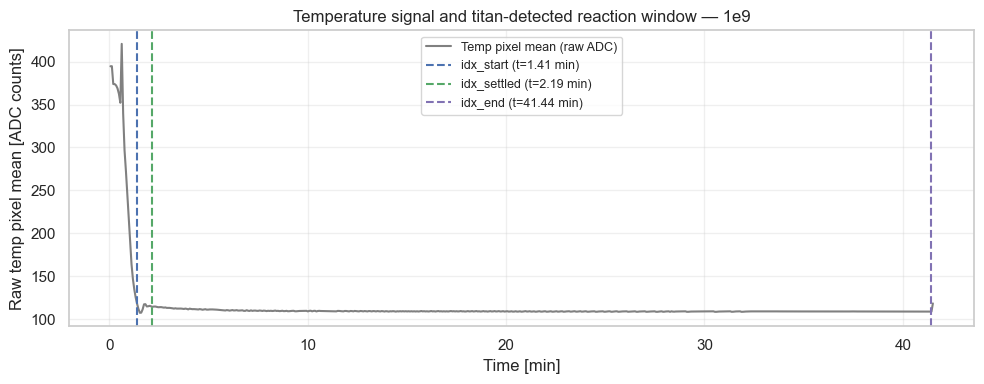


titan trims data to [idx_settled, idx_end] for downstream processing.
Trimmed length: 553 frames = 39.96 min from settling.


In [18]:
temp_3d = exp.temperature_3d
temp_avg = temp_3d.reshape(-1, temp_3d.shape[2]).mean(axis=0)
time_full_min = well0.time_npr / 60.0

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(time_full_min, temp_avg, color='gray', label='Temp pixel mean (raw ADC)')
for label, idx, color in [('idx_start', well0.idx_start, 'C0'),
                            ('idx_settled', well0.idx_settled, 'C2'),
                            ('idx_end', well0.idx_end, 'C4')]:
    ax.axvline(time_full_min[idx], color=color, linestyle='--',
               label=f'{label} (t={time_full_min[idx]:.2f} min)')
ax.set(xlabel='Time [min]', ylabel='Raw temp pixel mean [ADC counts]',
       title=f'Temperature signal and titan-detected reaction window — {EXP_LABEL}')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\ntitan trims data to [idx_settled, idx_end] for downstream processing.')
print(f'Trimmed length: {well0.well_2d_bs_active_mean.shape[0]} frames'
      f' = {well0.time_min[-1]:.2f} min from settling.')

## Per-pixel linearised + baseline-subtracted traces (well 0)

Pick a few active pixels from well 0 and show their linearised V(t). After titan preprocessing they should:
- start near 0 V (baseline-subtracted to the first stable sample)
- rise during chemistry settling and amplification
- have similar shapes (per-pixel offsets / trapped-charge removed)

/var/folders/v7/8k5h67q928l4b3dxxs2wxvg80000gn/T/ipykernel_12118/3283311742.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.grid(alpha=0.3); ax.legend(fontsize=8, loc='best')


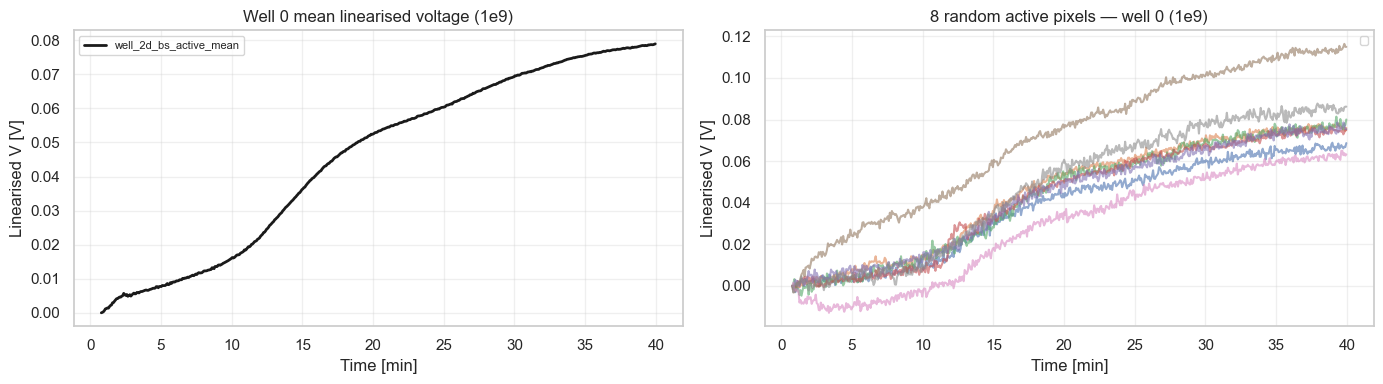

In [19]:
well0_2d_lin = well0.well_2d_bs_active   # shape (T, n_active)
n_active = well0_2d_lin.shape[1]
rng = np.random.default_rng(0)
sample_cols = rng.choice(n_active, size=min(8, n_active), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for c in sample_cols:
    axes[1].plot(well0.time_min, well0_2d_lin[:, c], alpha=0.6)
axes[0].plot(well0.time_min, well0.well_2d_bs_active_mean, 'k-', linewidth=2,
             label='well_2d_bs_active_mean')
axes[0].set(xlabel='Time [min]', ylabel='Linearised V [V]',
             title=f'Well 0 mean linearised voltage ({EXP_LABEL})')
axes[1].set(xlabel='Time [min]', ylabel='Linearised V [V]',
             title=f'8 random active pixels — well 0 ({EXP_LABEL})')
for ax in axes:
    ax.grid(alpha=0.3); ax.legend(fontsize=8, loc='best')
plt.tight_layout()
plt.show()

## All 6 wells — `well_2d_bs_active_mean`

This is the input to TTP extraction. One mean trace per well, computed from titan's per-pixel linearised voltage averaged over the active pixels.

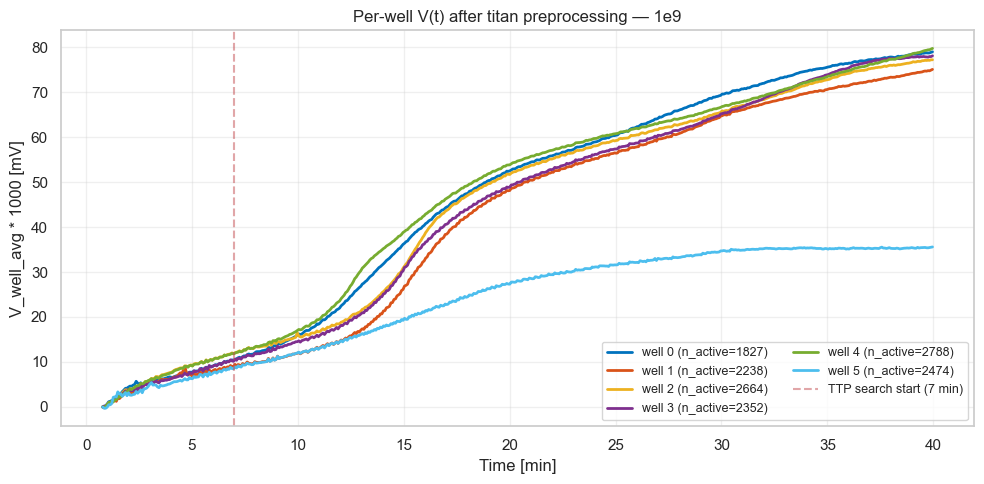


Observations:
 - All 6 wells of a 1e9 chip should look similar (same sample in every well).
 - Curves rise during settling, sigmoidally during amplification (~10-15 min for 1e9).
 - The red dashed line is where MATLAB-style TTP search begins.


In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
for i, well in enumerate(exp.wells_list):
    ax.plot(well.time_min, well.well_2d_bs_active_mean * 1e3, linewidth=2,
            color=MATLAB_COLORS[i],
            label=f'well {i} (n_active={int(well.idx_active.sum())})')
ax.axvline(SEARCH_START_MIN, color='r', linestyle='--', alpha=0.5,
           label=f'TTP search start ({SEARCH_START_MIN:.0f} min)')
ax.set(xlabel='Time [min]', ylabel='V_well_avg * 1000 [mV]',
       title=f'Per-well V(t) after titan preprocessing — {EXP_LABEL}')
ax.legend(loc='best', fontsize=9, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('\nObservations:')
print(' - All 6 wells of a 1e9 chip should look similar (same sample in every well).')
print(' - Curves rise during settling, sigmoidally during amplification (~10-15 min for 1e9).')
print(' - The red dashed line is where MATLAB-style TTP search begins.')

## Stage 7 — MATLAB-style TTP extraction in detail

Walk through the algorithm on well 0:

1. Smooth V(t) with a centered moving average of order 100
2. Take `diff`, then smooth again with order 100 → `diff_smooth` (the order-100 derivative)
3. Find peaks of `diff_smooth` within `[search_start, search_end]`, pick the one with the **largest PKS × Width**
4. Take the raw (order-1) `diff_raw = diff(V)`
5. **TTP** = the LAST sample before the peak where `diff_raw` falls below `min(diff_smooth[start:peak]) + 0.4 × (peak - min)`

In [21]:
def smooth_centered(signal, span):
    """Centered moving average matching MATLAB's smooth(signal, span).
    Even spans are effectively rounded down to the nearest odd integer
    (matching MATLAB's behaviour: smooth(., 100) uses a 99-sample window).
    """
    if span <= 1: return signal.copy()
    n = len(signal); half = (span - 1) // 2
    out = np.empty(n)
    for i in range(n):
        out[i] = np.mean(signal[max(0, i - half):min(n, i + half + 1)])
    return out

def extract_ttp_matlab_style(time_min, signal,
                              search_start_min=SEARCH_START_MIN,
                              search_end_min=SEARCH_END_MIN,
                              smooth_order=SMOOTH_ORDER,
                              threshold_frac=THRESHOLD_FRAC):
    idx_start = int(np.searchsorted(time_min, search_start_min))
    idx_end = int(np.searchsorted(time_min, search_end_min))
    if idx_end >= len(signal): idx_end = len(signal) - 1
    diff_raw = np.diff(signal)
    sig_smooth = smooth_centered(signal, smooth_order)
    diff_smooth = smooth_centered(np.diff(sig_smooth), smooth_order)
    if idx_end > len(diff_smooth): idx_end = len(diff_smooth)
    region = diff_smooth[idx_start:idx_end]
    if len(region) < 10: return np.nan, np.nan, diff_raw, diff_smooth
    peaks, props = find_peaks(region, width=1)
    if len(peaks) == 0: return np.nan, np.nan, diff_raw, diff_smooth
    best = int(np.argmax(region[peaks] * props['widths']))
    peak_loc = int(peaks[best] + idx_start)
    peak_time = float(time_min[peak_loc])
    pre = diff_smooth[idx_start:peak_loc + 1]
    thr = float(pre.min() + threshold_frac * (diff_smooth[peak_loc] - pre.min()))
    below = np.where(diff_raw[idx_start:peak_loc + 1] < thr)[0]
    if len(below) == 0: return np.nan, peak_time, diff_raw, diff_smooth
    return float(time_min[idx_start + below[-1]]), peak_time, diff_raw, diff_smooth

Well 0:  TTP = 12.25 min,   peak = 14.25 min


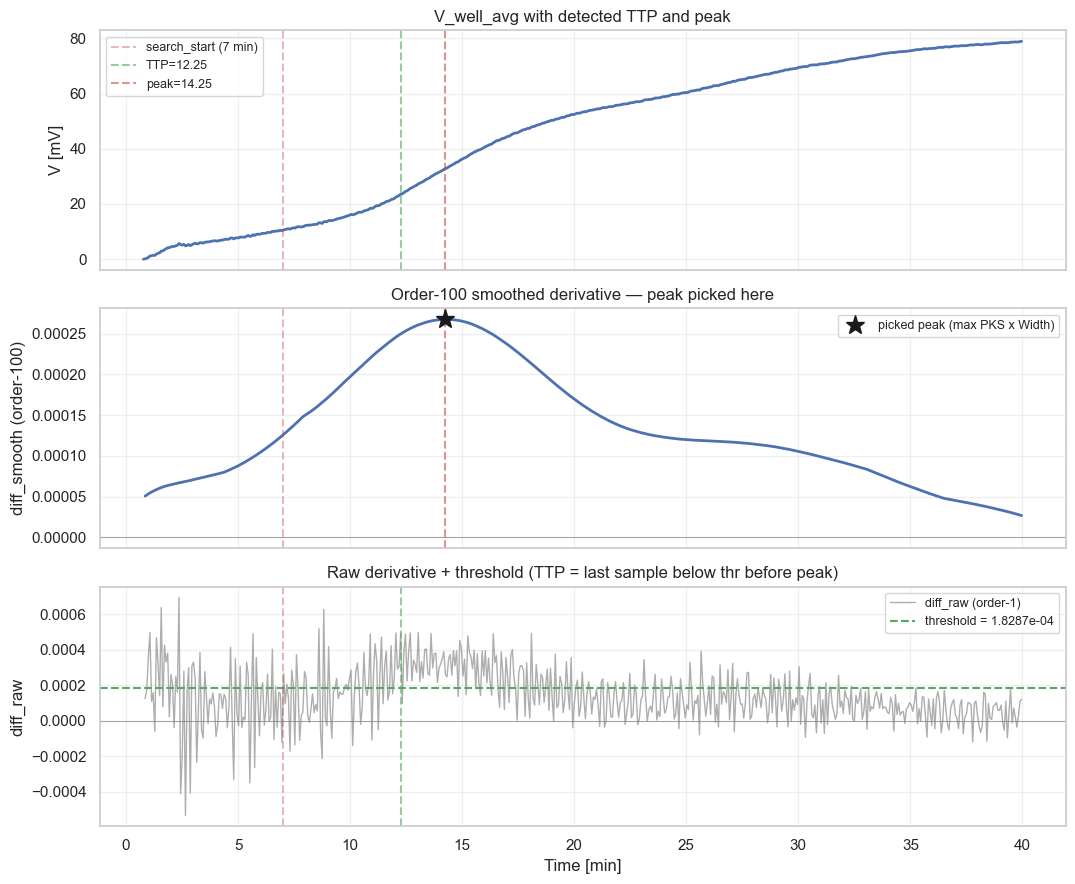

In [22]:
# Walk through TTP extraction for well 0
well = exp.wells_list[0]
ttp, peak, diff_raw, diff_smooth = extract_ttp_matlab_style(
    well.time_min, well.well_2d_bs_active_mean)
print(f'Well 0:  TTP = {ttp:.2f} min,   peak = {peak:.2f} min')

t_d = well.time_min[1:1 + len(diff_raw)]
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
# Top: V(t) with markers
axes[0].plot(well.time_min, well.well_2d_bs_active_mean * 1e3, linewidth=2)
axes[0].axvline(SEARCH_START_MIN, color='r', linestyle='--', alpha=0.4,
                 label=f'search_start ({SEARCH_START_MIN:.0f} min)')
axes[0].axvline(ttp, color='C2', linestyle='--', alpha=0.6, label=f'TTP={ttp:.2f}')
axes[0].axvline(peak, color='C3', linestyle='--', alpha=0.6, label=f'peak={peak:.2f}')
axes[0].set(ylabel='V [mV]', title='V_well_avg with detected TTP and peak')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)
# Middle: order-100 smoothed derivative
axes[1].plot(t_d, diff_smooth, linewidth=2, color='C0')
axes[1].axvline(SEARCH_START_MIN, color='r', linestyle='--', alpha=0.4)
axes[1].axvline(peak, color='C3', linestyle='--', alpha=0.6)
if not np.isnan(peak):
    pk_idx = int(np.searchsorted(t_d, peak))
    if pk_idx < len(diff_smooth):
        axes[1].plot(peak, diff_smooth[pk_idx], 'k*', markersize=14,
                     label='picked peak (max PKS x Width)')
axes[1].set(ylabel='diff_smooth (order-100)',
             title='Order-100 smoothed derivative — peak picked here')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)
axes[1].axhline(0, color='gray', linewidth=0.5)
# Bottom: raw diff with threshold
axes[2].plot(t_d, diff_raw, linewidth=1, color='C7', alpha=0.7,
              label='diff_raw (order-1)')
if not np.isnan(peak):
    idx_start_d = int(np.searchsorted(t_d, SEARCH_START_MIN))
    pk_idx = int(np.searchsorted(t_d, peak))
    pre = diff_smooth[idx_start_d:pk_idx + 1]
    thr = float(pre.min() + THRESHOLD_FRAC * (diff_smooth[pk_idx] - pre.min()))
    axes[2].axhline(thr, color='C2', linestyle='--', linewidth=1.5,
                     label=f'threshold = {thr:.4e}')
axes[2].axvline(SEARCH_START_MIN, color='r', linestyle='--', alpha=0.4)
axes[2].axvline(ttp, color='C2', linestyle='--', alpha=0.6)
axes[2].set(xlabel='Time [min]', ylabel='diff_raw',
             title='Raw derivative + threshold (TTP = last sample below thr before peak)')
axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3)
axes[2].axhline(0, color='gray', linewidth=0.5)
plt.tight_layout()
plt.show()

## All 6 wells of the chip — TTPs and peaks

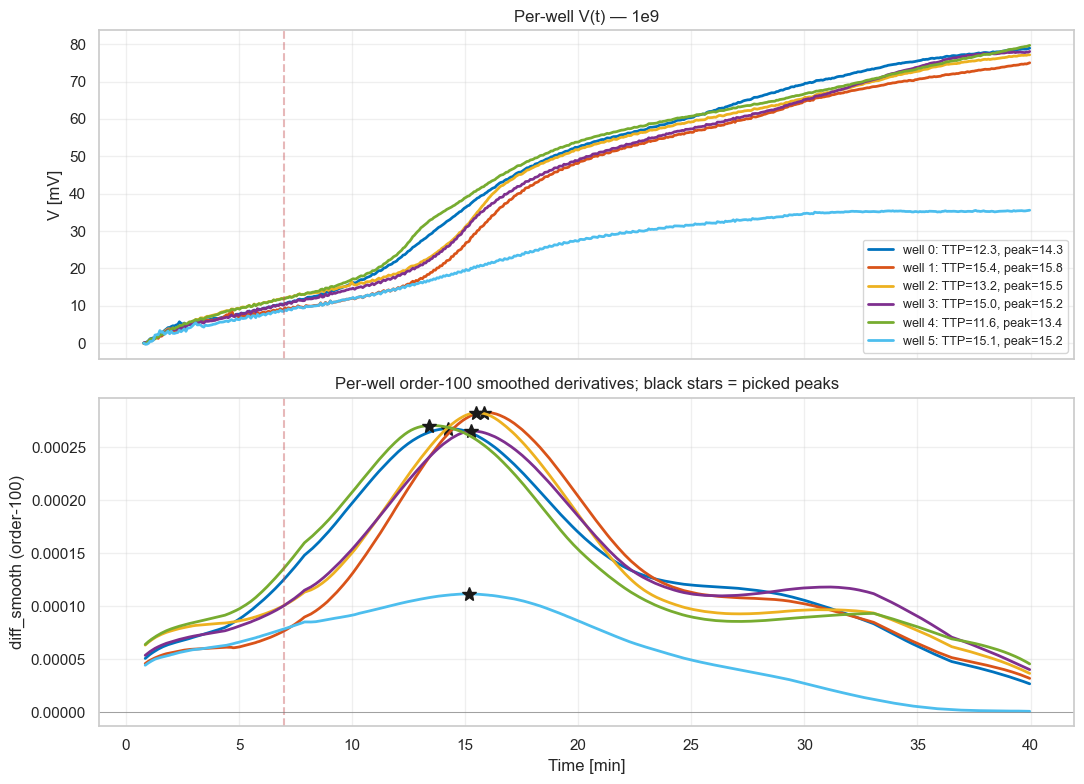


Mean over wells 0-3 (the supervisor`s ampl_peaks(:,1:4) convention):
  TTP  mean: 13.97 min
  peak mean: 15.20 min


In [23]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
ttps_w, peaks_w = [], []
for i, well in enumerate(exp.wells_list):
    ttp, peak, _, diff_smooth = extract_ttp_matlab_style(
        well.time_min, well.well_2d_bs_active_mean)
    ttps_w.append(ttp); peaks_w.append(peak)
    t_d = well.time_min[1:1 + len(diff_smooth)]
    axes[0].plot(well.time_min, well.well_2d_bs_active_mean * 1e3, linewidth=2,
                 color=MATLAB_COLORS[i],
                 label=f'well {i}: TTP={ttp:.1f}, peak={peak:.1f}')
    axes[1].plot(t_d, diff_smooth, linewidth=2, color=MATLAB_COLORS[i])
    if not np.isnan(peak):
        pk_idx = int(np.searchsorted(t_d, peak))
        if pk_idx < len(diff_smooth):
            axes[1].plot(peak, diff_smooth[pk_idx], 'k*', markersize=10)
for ax in axes:
    ax.axvline(SEARCH_START_MIN, color='r', linestyle='--', alpha=0.4)
    ax.grid(alpha=0.3)
axes[0].set(ylabel='V [mV]', title=f'Per-well V(t) — {EXP_LABEL}')
axes[0].legend(fontsize=9, loc='lower right')
axes[1].set(xlabel='Time [min]', ylabel='diff_smooth (order-100)',
             title='Per-well order-100 smoothed derivatives; black stars = picked peaks')
axes[1].axhline(0, color='gray', linewidth=0.5)
plt.tight_layout()
plt.show()

print(f'\nMean over wells 0-3 (the supervisor`s ampl_peaks(:,1:4) convention):')
print(f'  TTP  mean: {np.nanmean([ttps_w[w] for w in WELLS_FOR_QUANT]):.2f} min')
print(f'  peak mean: {np.nanmean([peaks_w[w] for w in WELLS_FOR_QUANT]):.2f} min')

## Run on all 5 Final chips and aggregate

In [24]:
all_results = {}
for ck, ep in EXPERIMENTS_FINAL.items():
    print(f'Loading {ck}...')
    e = titan_load_and_preprocessing(
        ep, n_wells=N_WELLS, start_type='temperature',
        n_a_type=N_A_TYPE, end_time_min=END_TIME_MIN, print_status=False)
    ttps, peaks = [], []
    for well in e.wells_list:
        ttp, peak, _, _ = extract_ttp_matlab_style(
            well.time_min, well.well_2d_bs_active_mean)
        ttps.append(ttp); peaks.append(peak)
    all_results[ck] = {'exp': e, 'ttps': ttps, 'peaks': peaks}
print('Done.')

Loading 1e5...
Loading 1e6...
Loading 1e7...
Loading 1e8...
Loading 1e9...
Done.


In [25]:
# Per-chip per-well summary tables
cols = [f'well {w}' for w in range(N_WELLS)]
ttp_df = pd.DataFrame({ck: all_results[ck]['ttps'] for ck in CONC_KEYS}, index=cols).T
ttp_df['mean wells 0-3'] = ttp_df[[f'well {w}' for w in WELLS_FOR_QUANT]].mean(axis=1)
peak_df = pd.DataFrame({ck: all_results[ck]['peaks'] for ck in CONC_KEYS}, index=cols).T
peak_df['mean wells 0-3'] = peak_df[[f'well {w}' for w in WELLS_FOR_QUANT]].mean(axis=1)
print('TTP per chip per well [min]:')
print(ttp_df.round(2))
print('\nAmplification peak per chip per well [min]:')
print(peak_df.round(2))

TTP per chip per well [min]:
     well 0  well 1  well 2  well 3  well 4  well 5  mean wells 0-3
1e5   27.91   25.08   25.64   27.91   11.60   26.80           26.63
1e6   25.05   25.05   22.55   23.47   13.40   28.20           24.03
1e7   18.36   21.95   19.17   23.22   15.23   29.33           20.67
1e8   17.10   19.64   19.83   19.64   14.68   29.76           19.05
1e9   12.26   15.39   13.18   15.04   11.61   15.10           13.97

Amplification peak per chip per well [min]:
     well 0  well 1  well 2  well 3  well 4  well 5  mean wells 0-3
1e5   28.09   25.21   25.76   27.97   13.45   26.86           26.76
1e6   25.18   25.25   22.82   23.54   15.78   28.40           24.20
1e7   19.05   22.06   20.33   23.33   15.28   29.45           21.19
1e8   17.29   19.70   20.01   19.64   14.93   29.76           19.16
1e9   14.25   15.82   15.46   15.25   13.40   15.18           15.20


## Slope plot — peak vs supervisor's `ampl_peaks`

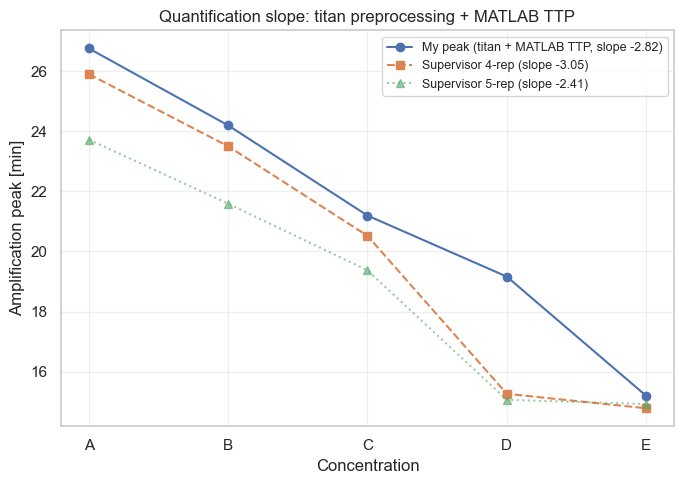

In [26]:
x = CONC_LOG
my_peaks_mean = np.array([np.nanmean([all_results[ck]['peaks'][w] for w in WELLS_FOR_QUANT])
                            for ck in CONC_KEYS])
fig, ax = plt.subplots(figsize=(7, 5))
slope_my = np.polyfit(x, my_peaks_mean, 1)[0]
ax.plot(x, my_peaks_mean, 'o-', color='C0',
        label=f'My peak (titan + MATLAB TTP, slope {slope_my:+.2f})')
slope_4 = np.polyfit(x, SUPERVISOR_AMPL_PEAKS_4REP, 1)[0]
slope_5 = np.polyfit(x, SUPERVISOR_AMPL_PEAKS_5REP, 1)[0]
ax.plot(x, SUPERVISOR_AMPL_PEAKS_4REP, 's--', color='C1',
        label=f'Supervisor 4-rep (slope {slope_4:+.2f})')
ax.plot(x, SUPERVISOR_AMPL_PEAKS_5REP, '^:', color='C2', alpha=0.6,
        label=f'Supervisor 5-rep (slope {slope_5:+.2f})')
ax.set_xticks(x); ax.set_xticklabels(EXP_LABELS)
ax.set_xlabel('Concentration'); ax.set_ylabel('Amplification peak [min]')
ax.set_title('Quantification slope: titan preprocessing + MATLAB TTP')
ax.grid(alpha=0.3); ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Per-well TTP scatter — 4 wells × 5 concentrations

The supervisor-style slide-5 layout, but for **TTP** rather than amplification peak. One coloured marker per well of each chip; black tick = mean of wells 0–3 with SE bar; black dashed = linear fit through the means.

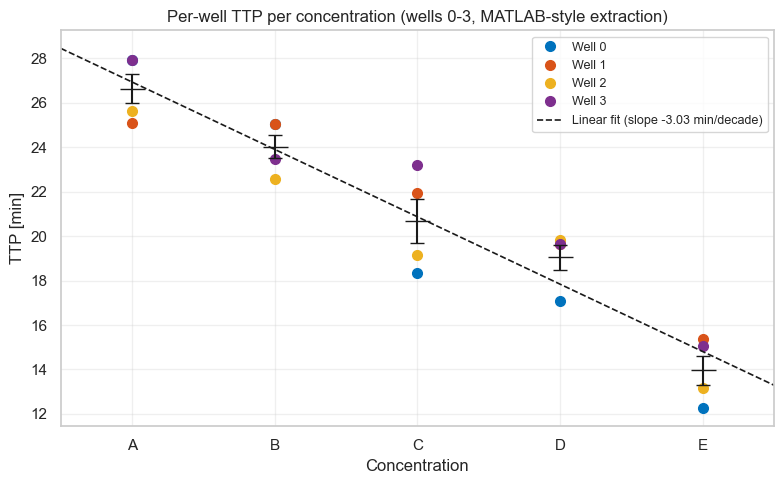


What to look at:
 - Each coloured dot = TTP of one specific well at one concentration.
 - Black tick = mean across wells 0-3 (SE bar shows within-chip spread).
 - Linear fit gives the slope (target: similar to supervisor`s ~-2.78 min/decade).
 - At 1e5 (low concentration) within-chip spread is the largest -> LoD reality.


In [27]:
fig, ax = plt.subplots(figsize=(8, 5))
ttp_means = []
for j, w in enumerate(WELLS_FOR_QUANT):
    ttps_for_well = np.array([all_results[ck]['ttps'][w] for ck in CONC_KEYS])
    ax.plot(x, ttps_for_well, '.', color=MATLAB_COLORS[j], markersize=14,
            label=f'Well {w}')
for i, ck in enumerate(CONC_KEYS):
    well_ttps = [all_results[ck]['ttps'][w] for w in WELLS_FOR_QUANT]
    mean_ttp = float(np.nanmean(well_ttps))
    se = float(np.nanstd(well_ttps) / np.sqrt(np.sum(~np.isnan(well_ttps))))
    ttp_means.append(mean_ttp)
    ax.errorbar(x[i], mean_ttp, yerr=se, fmt='k_', ms=18, lw=1.5, capsize=5, zorder=5)
means_arr = np.array(ttp_means)
valid = ~np.isnan(means_arr)
if valid.sum() >= 2:
    coeffs = np.polyfit(x[valid], means_arr[valid], 1)
    xf = np.linspace(x.min() - 0.5, x.max() + 0.5, 100)
    ax.plot(xf, np.polyval(coeffs, xf), 'k--', lw=1.2,
            label=f'Linear fit (slope {coeffs[0]:+.2f} min/decade)')
ax.set_xticks(x); ax.set_xticklabels(EXP_LABELS)
ax.set_xlim([x.min() - 0.5, x.max() + 0.5])
ax.set_xlabel('Concentration'); ax.set_ylabel('TTP [min]')
ax.set_title('Per-well TTP per concentration (wells 0-3, MATLAB-style extraction)')
ax.grid(alpha=0.3); ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

print('\nWhat to look at:')
print(' - Each coloured dot = TTP of one specific well at one concentration.')
print(' - Black tick = mean across wells 0-3 (SE bar shows within-chip spread).')
print(' - Linear fit gives the slope (target: similar to supervisor`s ~-2.78 min/decade).')
print(' - At 1e5 (low concentration) within-chip spread is the largest -> LoD reality.')

## Summary

Produces the same numbers as `quantification.py` but with intermediate visualisations exposed at each stage. Use this notebook when you want to **see** what each step does; use the script when you want to regenerate the canonical CSVs and PNGs.